<a href="https://colab.research.google.com/github/MISHTI100/credit_card_fraud_detection/blob/main/Credit_Fraud_Detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install river kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from river import linear_model, metrics, preprocessing

In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset path:", path)
print("Files:", os.listdir(path))

file_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset path: /kaggle/input/creditcardfraud
Files: ['creditcard.csv']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
static_model = LogisticRegression(max_iter=1000)
static_model.fit(X_train, y_train)

y_static_pred = static_model.predict(X_test)

print("🔹 STATIC MODEL RESULTS")
print("Accuracy:", accuracy_score(y_test, y_static_pred))
print(classification_report(y_test, y_static_pred))

🔹 STATIC MODEL RESULTS
Accuracy: 0.9991573329588147
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.67      0.73        98

    accuracy                           1.00     56962
   macro avg       0.90      0.84      0.87     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
stream_data = X_test.copy()
stream_data['Class'] = y_test.values
stream_data = stream_data.reset_index(drop=True)

In [7]:
model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
metric = metrics.Accuracy()

In [8]:
y_preds = []
y_true = []

print("\n🚀 STARTING REAL-TIME FRAUD DETECTION...\n")

for i, row in stream_data.iterrows():

    x = row.drop('Class').to_dict()
    y = row['Class']

    # Predict
    y_pred = model.predict_one(x)

    if y_pred is None:
        y_pred = 0

    # 🚨 Alert System
    if y_pred == 1:
        print(f"🚨 FRAUD DETECTED at transaction {i}")
    else:
        print(f"✅ NORMAL transaction {i}")

    # Learn (Adaptive)
    model.learn_one(x, y)

    # Track performance
    metric.update(y, y_pred)
    y_preds.append(y_pred)
    y_true.append(y)

    # Simulate real-time
    time.sleep(0.1)

    # Limit for demo (IMPORTANT)
    if i > 300:
        break

print("\n✅ FINAL ONLINE ACCURACY:", metric.get())


🚀 STARTING REAL-TIME FRAUD DETECTION...

✅ NORMAL transaction 0
✅ NORMAL transaction 1
🚨 FRAUD DETECTED at transaction 2
🚨 FRAUD DETECTED at transaction 3
✅ NORMAL transaction 4
✅ NORMAL transaction 5
✅ NORMAL transaction 6
✅ NORMAL transaction 7
✅ NORMAL transaction 8
✅ NORMAL transaction 9
🚨 FRAUD DETECTED at transaction 10
✅ NORMAL transaction 11
✅ NORMAL transaction 12
✅ NORMAL transaction 13
✅ NORMAL transaction 14
✅ NORMAL transaction 15
✅ NORMAL transaction 16
✅ NORMAL transaction 17
🚨 FRAUD DETECTED at transaction 18
🚨 FRAUD DETECTED at transaction 19
✅ NORMAL transaction 20
🚨 FRAUD DETECTED at transaction 21
✅ NORMAL transaction 22
✅ NORMAL transaction 23
✅ NORMAL transaction 24
✅ NORMAL transaction 25
✅ NORMAL transaction 26
✅ NORMAL transaction 27
✅ NORMAL transaction 28
✅ NORMAL transaction 29
✅ NORMAL transaction 30
✅ NORMAL transaction 31
✅ NORMAL transaction 32
✅ NORMAL transaction 33
✅ NORMAL transaction 34
✅ NORMAL transaction 35
🚨 FRAUD DETECTED at transaction 36
✅ N

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


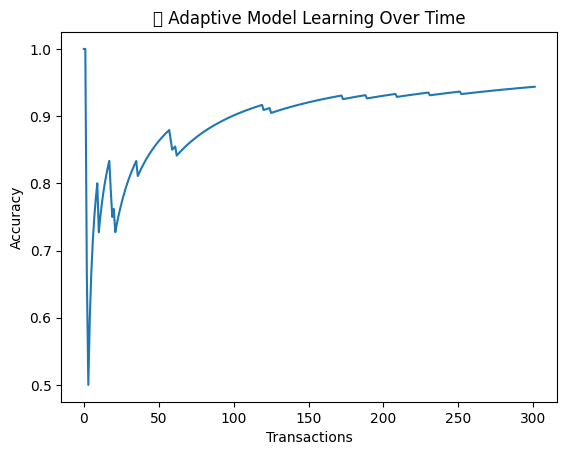

In [9]:
acc_list = []
metric_plot = metrics.Accuracy()

for i in range(len(y_true)):
    metric_plot.update(y_true[i], y_preds[i])
    acc_list.append(metric_plot.get())

plt.figure()
plt.plot(acc_list)
plt.title("📈 Adaptive Model Learning Over Time")
plt.xlabel("Transactions")
plt.ylabel("Accuracy")
plt.show()

In [10]:
print("\n📊 FINAL COMPARISON")
print("Static Accuracy:", accuracy_score(y_test, y_static_pred))
print("Adaptive Accuracy:", metric.get())


📊 FINAL COMPARISON
Static Accuracy: 0.9991573329588147
Adaptive Accuracy: 0.9437086092715232


In [15]:
# Pre-train model on many samples
for i, row in stream_data.iterrows():
    x = row.drop('Class').to_dict()
    y = row['Class']

    model.learn_one(x, y)

    if i > 3000:   # train properly
        break

print("✅ Model pre-trained")

✅ Model pre-trained


In [16]:
# Find correctly predicted NORMAL case
for i, row in stream_data.iterrows():

    x = row.drop('Class').to_dict()
    y = row['Class']

    pred = model.predict_one(x)

    if pred == 0 and y == 0:
        print("\n💳 FOUND NORMAL TRANSACTION")
        print("Prediction:", pred)
        print("Actual:", y)
        print("✅ NORMAL TRANSACTION")
        break


💳 FOUND NORMAL TRANSACTION
Prediction: False
Actual: 0.0
✅ NORMAL TRANSACTION


In [17]:
# Find a correct NORMAL case and print values
for i, row in stream_data.iterrows():

    x = row.drop('Class').to_dict()
    y = row['Class']

    pred = model.predict_one(x)

    if pred == 0 and y == 0:
        print("\n💳 FOUND NORMAL TRANSACTION")
        print("Input Values:\n", x)   # 👈 THIS IS IMPORTANT
        break


💳 FOUND NORMAL TRANSACTION
Input Values:
 {'Time': 160760.0, 'V1': -0.674466064578314, 'V2': 1.40810501967799, 'V3': -1.11062205357093, 'V4': -1.32836577843066, 'V5': 1.38899603254837, 'V6': -1.30843906707795, 'V7': 1.88587890268717, 'V8': -0.614232966299775, 'V9': 0.311652212453101, 'V10': 0.65075700363522, 'V11': -0.857784661547805, 'V12': -0.229961445775592, 'V13': -0.19981700479103, 'V14': 0.266371326329879, 'V15': -0.0465441684754424, 'V16': -0.741398089749789, 'V17': -0.605616644106022, 'V18': -0.39256818789208, 'V19': -0.162648311024695, 'V20': 0.394321820843914, 'V21': 0.0800842396026648, 'V22': 0.810033595602455, 'V23': -0.224327230436412, 'V24': 0.707899237446867, 'V25': -0.13583702273753, 'V26': 0.0451021964988772, 'V27': 0.533837219064273, 'V28': 0.291319252625364, 'Amount': -0.2612734105062506}


In [12]:
# Example manual input (you can change values)
manual_input = {
    'Time': 10000,
    'V1': -1.359807,
    'V2': -0.072781,
    'V3': 2.536347,
    'V4': 1.378155,
    'V5': -0.338321,
    'V6': 0.462388,
    'V7': 0.239599,
    'V8': 0.098698,
    'V9': 0.363787,
    'V10': 0.090794,
    'V11': -0.551600,
    'V12': -0.617801,
    'V13': -0.991390,
    'V14': -0.311169,
    'V15': 1.468177,
    'V16': -0.470401,
    'V17': 0.207971,
    'V18': 0.025791,
    'V19': 0.403993,
    'V20': 0.251412,
    'V21': -0.018307,
    'V22': 0.277838,
    'V23': -0.110474,
    'V24': 0.066928,
    'V25': 0.128539,
    'V26': -0.189115,
    'V27': 0.133558,
    'V28': -0.021053,
    'Amount': 149.62
}

prediction = model.predict_one(manual_input)

print("\n💳 MANUAL TRANSACTION RESULT")

if prediction == 1:
    print("🚨 FRAUD DETECTED")
else:
    print("✅ NORMAL TRANSACTION")


💳 MANUAL TRANSACTION RESULT
🚨 FRAUD DETECTED


In [13]:
manual_input_normal = {
    'Time': 50000,
    'V1': 0.2,
    'V2': 0.1,
    'V3': 1.2,
    'V4': 0.5,
    'V5': 0.3,
    'V6': 0.2,
    'V7': 0.1,
    'V8': 0.05,
    'V9': 0.2,
    'V10': 0.1,
    'V11': 0.3,
    'V12': 0.2,
    'V13': 0.1,
    'V14': 0.05,
    'V15': 0.4,
    'V16': 0.2,
    'V17': 0.1,
    'V18': 0.05,
    'V19': 0.2,
    'V20': 0.1,
    'V21': 0.05,
    'V22': 0.1,
    'V23': 0.02,
    'V24': 0.1,
    'V25': 0.2,
    'V26': 0.1,
    'V27': 0.05,
    'V28': 0.01,
    'Amount': 50
}

prediction = model.predict_one(manual_input_normal)

print("\n💳 MANUAL NORMAL TEST")

if prediction == 1:
    print("🚨 FRAUD DETECTED")
else:
    print("✅ NORMAL TRANSACTION")


💳 MANUAL NORMAL TEST
🚨 FRAUD DETECTED


In [14]:
manual_input_normal = {
    'Time': 100000,
    'V1': 0.1,
    'V2': 0.05,
    'V3': 1.0,
    'V4': 0.3,
    'V5': 0.2,
    'V6': 0.1,
    'V7': 0.05,
    'V8': 0.02,
    'V9': 0.1,
    'V10': 0.05,
    'V11': 0.2,
    'V12': 0.1,
    'V13': 0.05,
    'V14': 0.02,
    'V15': 0.3,
    'V16': 0.1,
    'V17': 0.05,
    'V18': 0.02,
    'V19': 0.1,
    'V20': 0.05,
    'V21': 0.02,
    'V22': 0.05,
    'V23': 0.01,
    'V24': 0.05,
    'V25': 0.1,
    'V26': 0.05,
    'V27': 0.02,
    'V28': 0.01,
    'Amount': 80
}

prediction = model.predict_one(manual_input_normal)

print("\n💳 MANUAL TEST (EXPECTED NORMAL)")

if prediction == 1:
    print("🚨 FRAUD DETECTED")
else:
    print("✅ NORMAL TRANSACTION")


💳 MANUAL TEST (EXPECTED NORMAL)
🚨 FRAUD DETECTED


In [19]:
manual_input_normal = {
    'Time': 160760.0,
    'V1': -0.674466064578314,
    'V2': 1.40810501967799,
    'V3': -1.11062205357093,
    'V4': -1.32836577843066,
    'V5': 1.38899603254837,
    'V6': -1.30843906707795,
    'V7': 1.88587890268717,
    'V8': -0.614232966299775,
    'V9': 0.311652212453101,
    'V10': 0.65075700363522,
    'V11': -0.857784661547805,
    'V12': -0.229961445775592,
    'V13': -0.19981700479103,
    'V14': 0.266371326329879,
    'V15': -0.0465441684754424,
    'V16': -0.741398089749789,
    'V17': -0.605616644106022,
    'V18': -0.39256818789208,
    'V19': -0.162648311024695,
    'V20': 0.394321820843914,
    'V21': 0.0800842396026648,
    'V22': 0.810033595602455,
    'V23': -0.224327230436412,
    'V24': 0.707899237446867,
    'V25': -0.13583702273753,
    'V26': 0.0451021964988772,
    'V27': 0.533837219064273,
    'V28': 0.291319252625364,
    'Amount': -0.2612734105062506
}
prediction = model.predict_one(manual_input_normal)

print("\n💳 MANUAL TEST (EXPECTED NORMAL)")

if prediction == 1:
    print("🚨 FRAUD DETECTED")
else:
    print("✅ NORMAL TRANSACTION")


💳 MANUAL TEST (EXPECTED NORMAL)
✅ NORMAL TRANSACTION


In [20]:
# Find another NORMAL case (different index)
count = 0

for i, row in stream_data.iterrows():

    x = row.drop('Class').to_dict()
    y = row['Class']

    pred = model.predict_one(x)

    if pred == 0 and y == 0:
        count += 1

        if count == 2:   # 👈 second normal case
            print("\n💳 SECOND NORMAL TRANSACTION")
            print(x)
            break


💳 SECOND NORMAL TRANSACTION
{'Time': 19847.0, 'V1': -2.82981594327279, 'V2': -2.76514921229269, 'V3': 2.53779295063997, 'V4': -1.07458042259191, 'V5': 2.84255889292598, 'V6': -2.15353644367205, 'V7': -1.79551885720369, 'V8': -0.250020372324704, 'V9': 3.07350426338358, 'V10': -1.00041794567463, 'V11': 1.85084176033081, 'V12': -1.54977887088034, 'V13': 1.25233673695303, 'V14': 0.963974373307274, 'V15': -0.481027223791626, 'V16': -0.14731917203129, 'V17': -0.209328171581066, 'V18': 1.05889790297841, 'V19': 0.397056508186649, 'V20': -0.515764693656115, 'V21': -0.295554564490287, 'V22': 0.109304966698836, 'V23': -0.81327196874425, 'V24': 0.0429955726118499, 'V25': -0.0276596849389052, 'V26': -0.910247054904536, 'V27': 0.110801759066737, 'V28': -0.511938134872381, 'Amount': -0.3058520715686588}


In [21]:
manual_input_normal_2 = {
    'Time': 19847.0,
    'V1': -2.82981594327279,
    'V2': -2.76514921229269,
    'V3': 2.53779295063997,
    'V4': -1.07458042259191,
    'V5': 2.84255889292598,
    'V6': -2.15353644367205,
    'V7': -1.79551885720369,
    'V8': -0.250020372324704,
    'V9': 3.07350426338358,
    'V10': -1.00041794567463,
    'V11': 1.85084176033081,
    'V12': -1.54977887088034,
    'V13': 1.25233673695303,
    'V14': 0.963974373307274,
    'V15': -0.481027223791626,
    'V16': -0.14731917203129,
    'V17': -0.209328171581066,
    'V18': 1.05889790297841,
    'V19': 0.397056508186649,
    'V20': -0.515764693656115,
    'V21': -0.295554564490287,
    'V22': 0.109304966698836,
    'V23': -0.81327196874425,
    'V24': 0.0429955726118499,
    'V25': -0.0276596849389052,
    'V26': -0.910247054904536,
    'V27': 0.110801759066737,
    'V28': -0.511938134872381,
    'Amount': -0.3058520715686588
}
prediction = model.predict_one(manual_input_normal)

print("\n💳 MANUAL TEST (EXPECTED NORMAL)")

if prediction == 1:
    print("🚨 FRAUD DETECTED")
else:
    print("✅ NORMAL TRANSACTION")


💳 MANUAL TEST (EXPECTED NORMAL)
✅ NORMAL TRANSACTION


In [29]:
# Get ANY fraud case from dataset (guaranteed)
for i, row in stream_data.iterrows():

    x = row.drop('Class').to_dict()
    y = row['Class']

    if y == 1:   # only check actual fraud
        print("\n🚨 FOUND FRAUD TRANSACTION")
        print(x)
        break


🚨 FOUND FRAUD TRANSACTION
{'Time': 57007.0, 'V1': -1.27124419171437, 'V2': 2.46267526851135, 'V3': -2.85139500331783, 'V4': 2.3244800653478, 'V5': -1.37224488981369, 'V6': -0.948195686538643, 'V7': -3.06523436172054, 'V8': 1.16692694787211, 'V9': -2.26877058844813, 'V10': -4.88114292689057, 'V11': 2.25514748870463, 'V12': -4.68638689759229, 'V13': 0.652374668512965, 'V14': -6.17428834800643, 'V15': 0.594379608016446, 'V16': -4.84969238709652, 'V17': -6.53652073527011, 'V18': -3.11909388163881, 'V19': 1.71549441975915, 'V20': 0.560478075726644, 'V21': 0.652941051330455, 'V22': 0.0819309763507574, 'V23': -0.221347831198339, 'V24': -0.523582159233306, 'V25': 0.224228161862968, 'V26': 0.756334522703558, 'V27': 0.632800477330469, 'V28': 0.250187092757197, 'Amount': -0.35318941210488414}


In [30]:
manual_input_fraud = {
    'Time': 57007.0,
    'V1': -1.27124419171437,
    'V2': 2.46267526851135,
    'V3': -2.85139500331783,
    'V4': 2.3244800653478,
    'V5': -1.37224488981369,
    'V6': -0.948195686538643,
    'V7': -3.06523436172054,
    'V8': 1.16692694787211,
    'V9': -2.26877058844813,
    'V10': -4.88114292689057,
    'V11': 2.25514748870463,
    'V12': -4.68638689759229,
    'V13': 0.652374668512965,
    'V14': -6.17428834800643,
    'V15': 0.594379608016446,
    'V16': -4.84969238709652,
    'V17': -6.53652073527011,
    'V18': -3.11909388163881,
    'V19': 1.71549441975915,
    'V20': 0.560478075726644,
    'V21': 0.652941051330455,
    'V22': 0.0819309763507574,
    'V23': -0.221347831198339,
    'V24': -0.523582159233306,
    'V25': 0.224228161862968,
    'V26': 0.756334522703558,
    'V27': 0.632800477330469,
    'V28': 0.250187092757197,
    'Amount': -0.35318941210488414
}
proba = model.predict_proba_one(manual_input_fraud)
fraud_score = proba.get(1, 0)

print("\n🚨 FRAUD TEST RESULT")
print("Fraud Probability:", fraud_score)

if fraud_score > 0.3:
    print("🚨 FRAUD DETECTED")
else:
    print("❌ NORMAL TRANSACTION")


🚨 FRAUD TEST RESULT
Fraud Probability: 0.027337626801808547
❌ NORMAL TRANSACTION
